# 基金份额日变化量 (unit_chg) — 国家队注入模拟

---

## 1. 因子定义 (Wind 口径)

| 项目 | 内容 |
|------|------|
| **Wind 字段** | `f_unit_chg` |
| **中文名** | 基金份额日变化量 |
| **单位** | 万份 |
| **算法** | 指定日期基金总份额（含各子份额） |
| **来源** | 基金成立合同、上市公告、折算公告、定期报告 |

> **核心含义**: 反映 ETF 当前存在的总份额数。份额增加意味着有人通过一级市场申购了 ETF，份额减少意味着有人赎回。

---

## 2. 国家队操作影响分析

### 场内买入 → 对 unit_chg **无影响**
- 场内买入仅在二级市场上转让已有份额
- 买方获得份额的同时卖方失去等量份额，**总份额不变**
- 只有一级市场的申购/赎回才会改变总份额

### 场外申购 → **T+2** 影响 unit_chg
- 国家队通过一级市场申购，基金公司创建新份额
- T 日提交申购 → T+1 日确认 → **T+2 日新份额正式计入基金总份额**
- 新增份额 = 申购金额 / 单位净值 (NAV)

| 操作类型 | 是否影响 | 生效时间 | 原因 |
|---------|---------|---------|------|
| 场内买入 | **否** | — | 二级市场交易不创造/消灭份额 |
| 场外申购 | **是** | **T+2** | 一级市场创建新份额，T+2 确认到账 |

---

## 3. Δ 计算公式

```text
Δunit_chg = 申购金额 (万元) / NAV (元/份)   → 结果单位: 万份
```

**推导**: 投入 X 万元申购，按净值 NAV 换算，获得 X / NAV 万份新份额

**示例**: 申购 10 亿元 (100,000 万元)，NAV = 3.09 元 → Δ = 100,000 / 3.09 ≈ 32,362 万份

---

## 4. 模拟 Pipeline

```text
原始值 (raw) → 注入 delta 到 T+2 日 → Rolling Z-Score (窗口120, 最小60) → 相对因子 = z(A) − z(B)
```

---

## 5. 参数说明

| 参数 | 含义 | 影响 |
|------|------|------|
| `NAV_A / NAV_B` | 单位净值 (元/份) | **直接决定 Δ**: 同样金额，NAV 越低新增份额越多 |
| `AUM_A / AUM_B` | 资产管理规模 (亿元) | 决定买入金额按持仓市值比例分配 |
| `HOLD_PCT_A / HOLD_PCT_B` | 国家队持有比例 | 持仓价值 = HOLD_PCT × AUM，按比例分配总买入额 |
| `BUY_OFF_EXCHANGE` | 场外申购总额 (亿元) | 唯一影响渠道 |
| `BUY_ON_EXCHANGE` | 场内买入总额 (亿元) | 对本因子无影响，设为 0 |

---

## 6. 对大盘减小盘风格（y）的预期影响时间

> `y = 上证50日收益率 − 上证1000日收益率`。本因子作为**预测信号**，通过捕捉国家队资金偏好差异，预测大盘相对小盘的超额表现。

| 路径 | 预期影响时间 | 说明 |
|------|------------|------|
| 场外申购 → 通过本因子信号 | **T+2 ~ T+5** | 因子在T+2（新份额计入总份额）生效，叠加回归预测滞后 0–3 期 |
| 场内买入 → 直接价格冲击 | **T+0** | 场内买入当日推高大盘ETF价格，但不影响本因子，仅为直接价格效应 |

> **结论**: 国家队 T+0 出手 → 直接价格效应当日体现；通过本因子的信号传导，预期影响 y 的时间窗口见上表。


In [1]:
# ══════════════ 参数设置 (修改这里) ══════════════

# ── ETF 代码 ──
CODE_A = "510050.SH"
CODE_B = "510100.SH"

# ── ETF 基础参数 (影响 delta 计算, 可根据实际值调整) ──
NAME_A  = "华夏上证50ETF"
NAME_B  = "易方达上证50ETF"
AUM_A   = 1750                # ETF A 资产管理规模 (亿元)
AUM_B   = 46                  # ETF B 资产管理规模 (亿元)
NAV_A   = 3.09                # ETF A 单位净值 (元/份) ← 用于Δ计算
NAV_B   = 2.93                # ETF B 单位净值 (元/份)
SHARES_A = 5_670_000          # ETF A 总份额 (万份)
SHARES_B = 157_000            # ETF B 总份额 (万份)
DAILY_AMT_A = 200_000         # ETF A 日均成交额 (万元)
DAILY_AMT_B = 50_000          # ETF B 日均成交额 (万元)

# ── 模拟设置 ──
SIM_DATE = "2024-09-24"
HOLD_PCT_A = 0.70
HOLD_PCT_B = 0.30

BUY_ON_EXCHANGE  = 30.0        # 对unit_total无影响
BUY_OFF_EXCHANGE = 30.0       # 场外申购 (亿元) → T+2

ZOOM_HALF = 30

In [2]:
import datetime, sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
sys.path.insert(0, ".")
from sim_utils import *  # includes diff_zscore_sheet
setup_style()

SHEET = "unit_total"  # Excel sheet name (keep as-is for loading)
UNIT = "万份"
LAG = 2

sim_date = datetime.datetime.strptime(SIM_DATE, "%Y-%m-%d").date()
off_a, off_b = buy_split(BUY_OFF_EXCHANGE, AUM_A, AUM_B, HOLD_PCT_A, HOLD_PCT_B)

delta_a = off_a * 10000 / NAV_A
delta_b = off_b * 10000 / NAV_B

print(f"ETF对: {NAME_A} ({CODE_A}) vs {NAME_B} ({CODE_B})")
print(f"  AUM: {AUM_A}亿 vs {AUM_B}亿 | NAV: {NAV_A}元 vs {NAV_B}元")
print(f"场外申购: {BUY_OFF_EXCHANGE}亿 → {NAME_A} {off_a:.2f}亿, {NAME_B} {off_b:.2f}亿")
print(f"\nΔ unit_total:")
print(f"  {CODE_A}: +{delta_a:,.0f} {UNIT} (= {off_a*10000:,.0f}万元 / {NAV_A}元)")
print(f"  {CODE_B}: +{delta_b:,.0f} {UNIT} (= {off_b*10000:,.0f}万元 / {NAV_B}元)")

ETF对: 华夏上证50ETF (510050.SH) vs 易方达上证50ETF (510100.SH)
  AUM: 1750亿 vs 46亿 | NAV: 3.09元 vs 2.93元
场外申购: 30.0亿 → 华夏上证50ETF 29.67亿, 易方达上证50ETF 0.33亿

Δ unit_total:
  510050.SH: +96,006 万份 (= 296,658万元 / 3.09元)
  510100.SH: +1,141 万份 (= 3,342万元 / 2.93元)


In [3]:
sheets_raw = load_raw()
df_orig = sheets_raw[SHEET]
all_dates = sorted(df_orig[DATE_COL].dropna().unique())
t1 = offset_date(all_dates, sim_date, 1)
t2 = offset_date(all_dates, sim_date, LAG)
print(f"T+0={sim_date}, T+2={t2} (生效日)")

df_mod = inject_one(inject_one(df_orig, t2, CODE_A, delta_a), t2, CODE_B, delta_b)

z_before = diff_zscore_sheet(df_orig)
z_after  = diff_zscore_sheet(df_mod)
rel_before = relative_factor(z_before, CODE_A, CODE_B)
rel_after  = relative_factor(z_after, CODE_A, CODE_B)

zoom = zoom_range(all_dates, sim_date, ZOOM_HALF)
mask = df_orig[DATE_COL].isin(zoom)
dates = list(df_orig.loc[mask, DATE_COL])

T+0=2024-09-24, T+2=2024-09-26 (生效日)


In [4]:
import importlib, sim_utils; importlib.reload(sim_utils); from sim_utils import *  # includes diff_zscore_sheet

print_detail(df_orig, df_mod, z_before, z_after,
             CODE_A, CODE_B, NAME_A, NAME_B, UNIT,
             sim_date, all_dates, effect_date=t2, half=5)


  华夏上证50ETF (510050.SH)  —  单位: 万份
          日期 |      raw_bef      raw_aft |   mean_bef   mean_aft |    std_bef    std_aft |   z_bef   z_aft      Δz |
-------------------------------------------------------------------------------------------------------------------
  2024-09-13 |    5,522,017    5,522,017 |  4,868,399  4,868,399 |    381,017    381,017 |  -0.309  -0.309  +0.000 |
  2024-09-18 |    5,507,797    5,507,797 |  4,879,508  4,879,508 |    384,945    384,945 |  -0.652  -0.652  +0.000 |
  2024-09-19 |    5,500,597    5,500,597 |  4,890,953  4,890,953 |    387,950    387,950 |  -0.484  -0.484  +0.000 |
  2024-09-20 |    5,542,807    5,542,807 |  4,903,087  4,903,087 |    391,093    391,093 |   0.781   0.781  +0.000 |
  2024-09-23 |    5,543,257    5,543,257 |  4,915,470  4,915,470 |    393,542    393,542 |  -0.311  -0.311  +0.000 |
  2024-09-24 |    5,477,107    5,477,107 |  4,927,497  4,927,497 |    393,987    393,987 |  -2.007  -2.007  +0.000 | ★T+0
  2024-09-25 |    5,456,

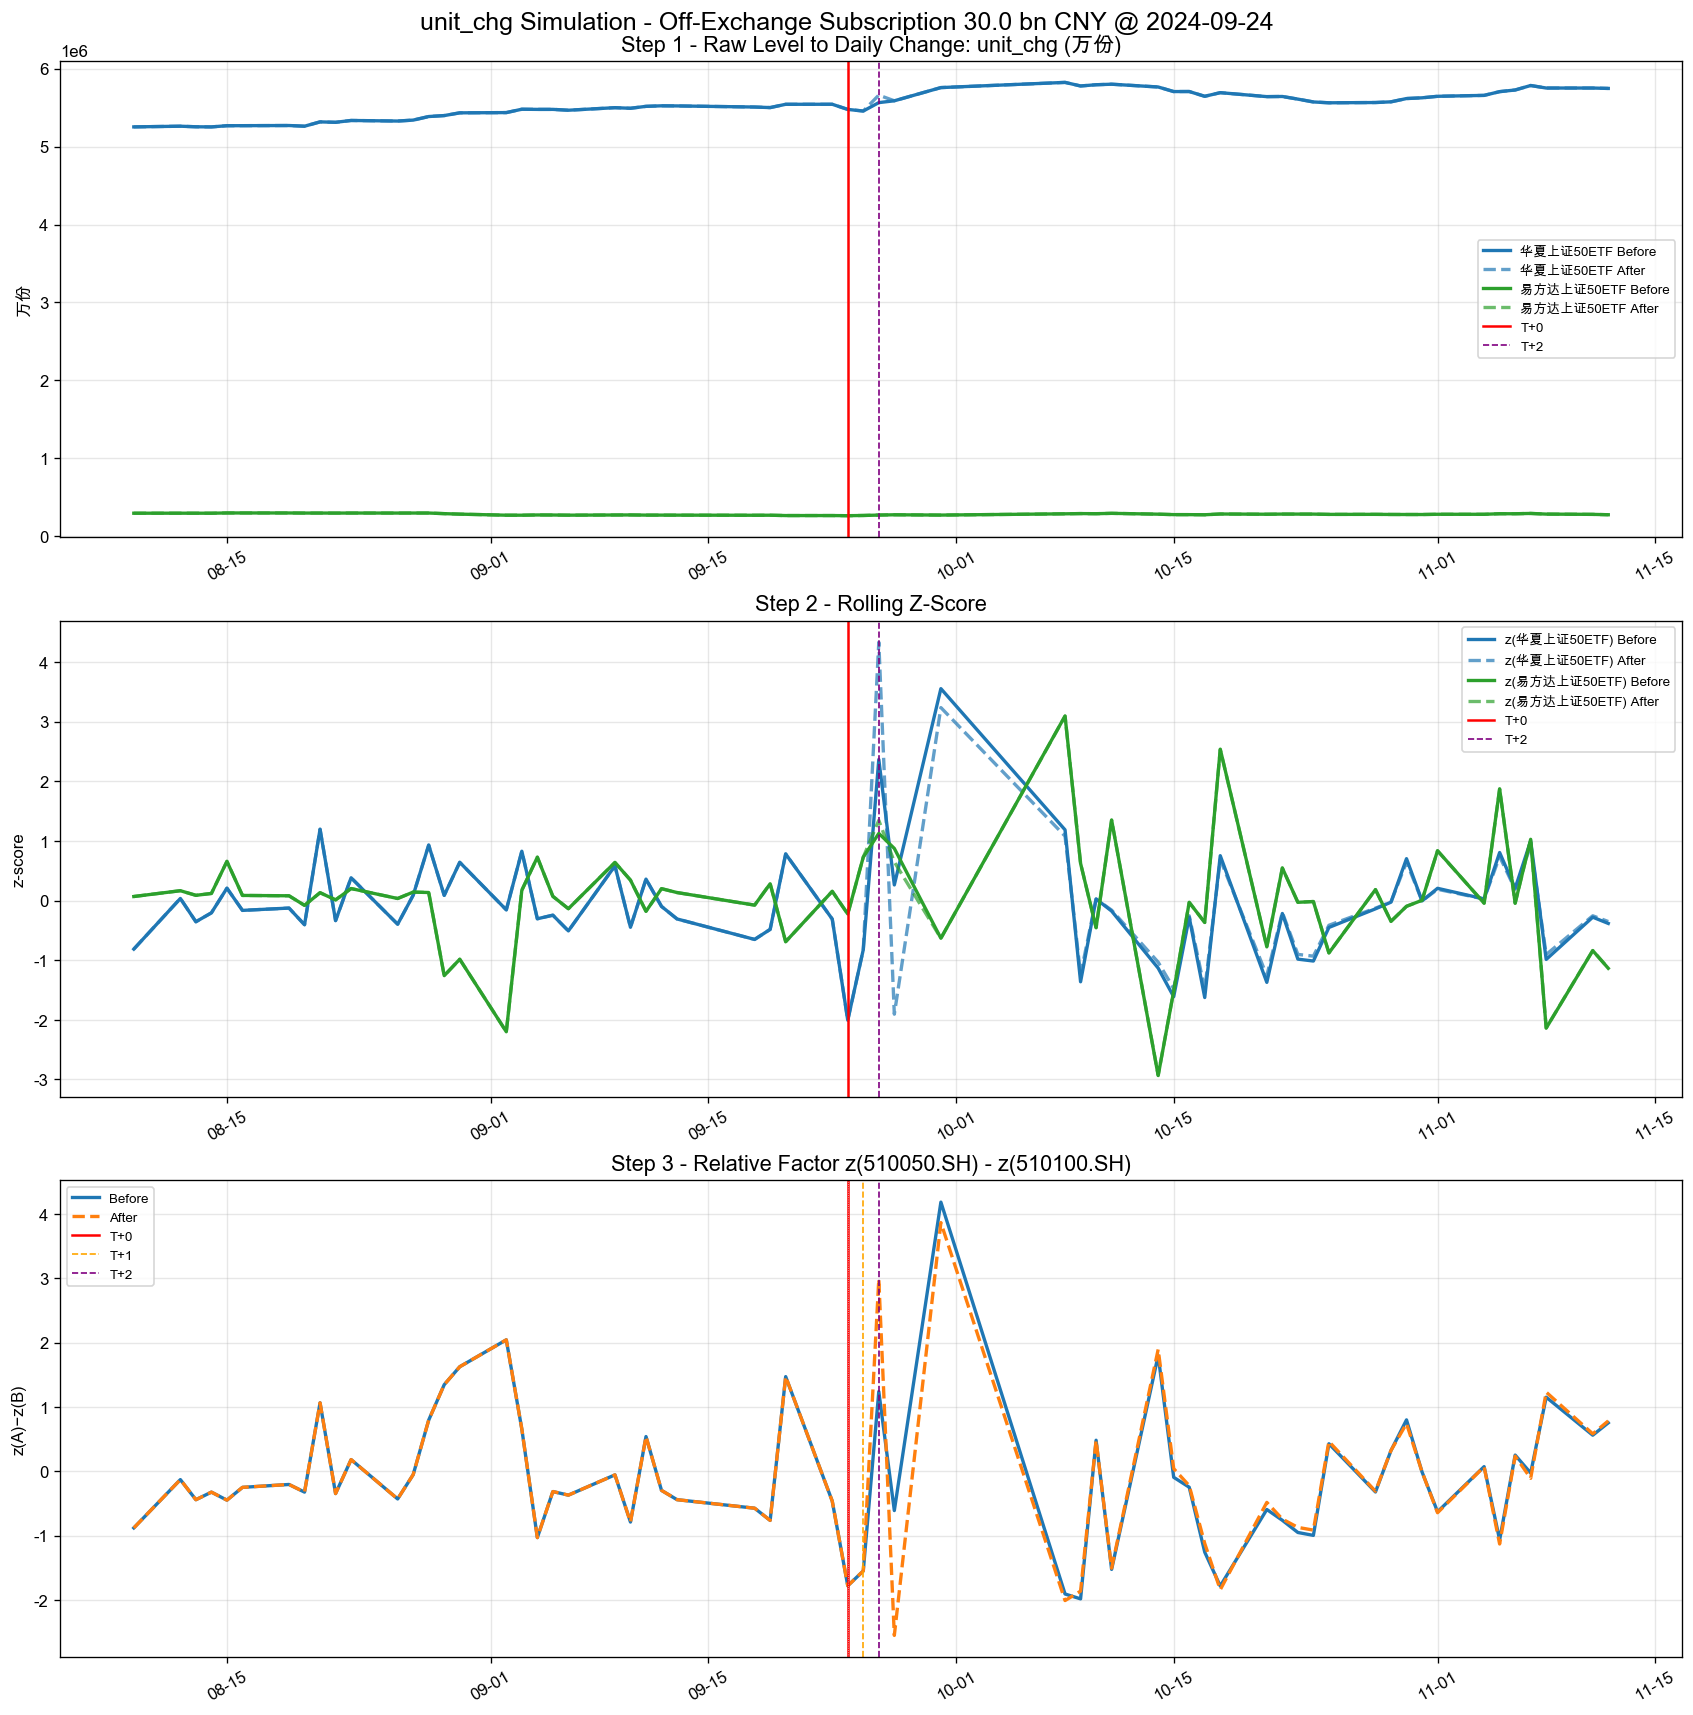

In [5]:
import pandas as pd
fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[0].plot(dates, pd.to_numeric(df_orig.loc[mask, code], errors='coerce').tolist(), label=f'{label} Before', color=c, lw=2)
    axes[0].plot(dates, pd.to_numeric(df_mod.loc[mask, code], errors='coerce').tolist(), label=f'{label} After', color=c, lw=2, ls='--', alpha=0.7)
axes[0].axvline(sim_date, color='red', lw=1.5, label='T+0')
if t2 in zoom: axes[0].axvline(t2, color='purple', lw=1, ls='--', label='T+2')
axes[0].set_title(f'Step 1 - Raw Level to Daily Change: unit_chg ({UNIT})', fontsize=13)
axes[0].set_ylabel(UNIT); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[0].tick_params(axis='x', rotation=30)

for code, label, c in [(CODE_A, NAME_A, '#1f77b4'), (CODE_B, NAME_B, '#2ca02c')]:
    axes[1].plot(dates, z_before.loc[mask, code].tolist(), label=f'z({label}) Before', color=c, lw=2)
    axes[1].plot(dates, z_after.loc[mask, code].tolist(), label=f'z({label}) After', color=c, lw=2, ls='--', alpha=0.7)
axes[1].axvline(sim_date, color='red', lw=1.5, label='T+0')
if t2 in zoom: axes[1].axvline(t2, color='purple', lw=1, ls='--', label='T+2')
axes[1].set_title('Step 2 - Rolling Z-Score', fontsize=13)
axes[1].set_ylabel('z-score'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d')); axes[1].tick_params(axis='x', rotation=30)

plot_ba(axes[2], dates, rel_before[mask].tolist(), rel_after[mask].tolist(),
        f'Step 3 - Relative Factor z({CODE_A}) - z({CODE_B})', 'z(A)−z(B)', sim_date, t1, t2)

plt.suptitle(f'unit_chg Simulation - Off-Exchange Subscription {BUY_OFF_EXCHANGE} bn CNY @ {SIM_DATE}', fontsize=15, y=1.01)
plt.show()